***Módulos a Importar***

In [15]:
import sympy as sp
from sympy.physics.mechanics import dynamicsymbols, ReferenceFrame
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Punto 1

0. Funciones a Utilizar

In [ ]:
def lista_posiciones(lista_theta1, lista_theta2):

  lista_posx_p1 = []
  lista_posy_p1 = []

  for elemento_unico in range(len(lista_theta1)):
    theta1_unico = lista_theta1[elemento_unico]
    theta2_unico = lista_theta2[elemento_unico]
    lista_posx_p1.append(f_posicionx_p1(theta1_unico, theta2_unico))
    lista_posy_p1.append(f_posiciony_p1(theta1_unico, theta2_unico))

  return lista_posx_p1, lista_posy_p1

In [ ]:
def graficar_puntos(x1, y1, x2, y2, x3, y3):
    plt.figure(figsize=(8, 8))

    plt.plot(x1, y1, label="Punto 1")
    plt.plot(x2, y2, label="Punto 2")
    plt.plot(x3, y3, label="Punto 3")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Trayectoria de los 3 puntos")
    plt.axis("equal")
    plt.grid(True)
    plt.legend()

    plt.show()

In [44]:
def graficar_puntos(x1, y1, x2, y2, x3, y3):
    plt.figure(figsize=(8, 8))

    plt.plot(x1, y1, label="Punto 1")
    plt.plot(x2, y2, label="Punto 2")
    plt.plot(x3, y3, label="Punto 3")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Trayectoria de los 3 puntos")
    plt.axis("equal")
    plt.grid(True)
    plt.legend()

    plt.show()

1. Definición del Modelo

In [58]:
# 1. Definición de Variables
theta, theta2 = dynamicsymbols('theta theta2')
l1, l2, l3_min, s, px, py = sp.symbols('l1 l2 l3_min s px py')

# s == Que tanto se esta expandiendo desde su punto de compresión maximo (entre 0 y 20
# print)

# 2. Definición de Marcos
N = ReferenceFrame('N')
A = N.orientnew('A', 'Axis', (theta, N.z))
B = A.orientnew('B', 'Axis', (-theta2, A.z))

# 3. Definición de Medidas y Vectores
l3 = l3_min + s
offset = px*N.x + py*N.y
r1 = l1*A.x
r2 = -l2*B.x
r3 = l3*N.y

# 4. Definición de Ecuaciones y Loop
loop = r1 + r2 - r3 +offset
eq_x = loop.dot(N.x)
eq_y = loop.dot(N.y)
eq = [eq_x, eq_y]

# 5. Conversión a función numérica
fun_eq = sp.lambdify((theta, theta2, l1, l2, l3_min, s, px, py), eq, "numpy")

# 6. Fijación de Valores
val = {
    l1: 30,
    l2: 30,
    l3_min: 30,
    px: 10,
    py: 5,
}
s_val = np.linspace(0, 20, 100)

# 7. Aproach Numérico (hallar theta1 y theta2)

estimacion_angulos = [np.radians(45), np.radians(90)]
theta1_sol = []
theta2_sol = []

for s_num in s_val:
  regleta = lambda v: fun_eq(*v, val[l1],val[l2], val[l3_min],s_num,val[px],val[py])
  solu=fsolve(regleta,estimacion_angulos)
  theta1_sol.append(solu[0])
  theta2_sol.append(solu[1])
  estimacion_angulos=solu


print(theta1_sol)

[np.float64(0.8458878459989299), np.float64(0.8466238872863205), np.float64(0.8474080544191355), np.float64(0.8482396260100629), np.float64(0.849117901643537), np.float64(0.8500422013450084), np.float64(0.8510118650678792), np.float64(0.8520262521975991), np.float64(0.853084741072467), np.float64(0.854186728520681), np.float64(0.8553316294132025), np.float64(0.8565188762320053), np.float64(0.8577479186532955), np.float64(0.8590182231453035), np.float64(0.8603292725802545), np.float64(0.8616805658601463), np.float64(0.8630716175559658), np.float64(0.8645019575599958), np.float64(0.8659711307508755), np.float64(0.8674786966710822), np.float64(0.8690242292165281), np.float64(0.8706073163379644), np.float64(0.8722275597539081), np.float64(0.8738845746748145), np.float64(0.875577989538222), np.float64(0.8773074457546336), np.float64(0.8790725974638712), np.float64(0.8808731113016953), np.float64(0.882708666176456), np.float64(0.8845789530555759), np.float64(0.8864836747616709), np.float64(0

4. Gráfica Ángulo (D)

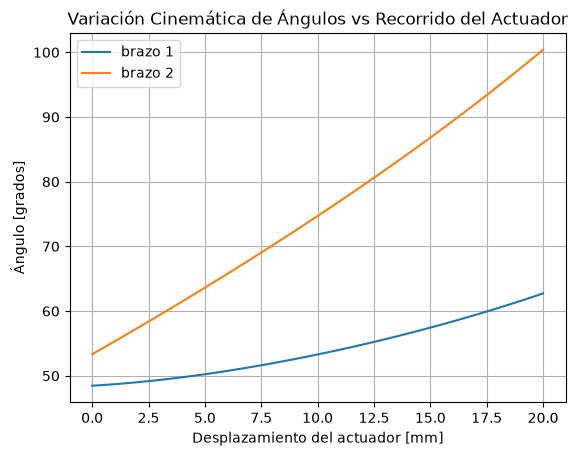

<class 'list'>
<class 'list'>


In [59]:
plt.plot(s_val, np.degrees(theta1_sol), label=r'brazo 1')
plt.plot(s_val, np.degrees(theta2_sol), label=r'brazo 2')
plt.xlabel('Desplazamiento del actuador [mm]')
plt.ylabel('Ángulo [grados]')
plt.title('Variación Cinemática de Ángulos vs Recorrido del Actuador')
plt.grid()
plt.legend()
plt.show()



print(type(theta1_sol))
print(type(theta2_sol))

B. Trayectoria en el Espacio de los Puntos

In [ ]:
dp1 = sp.symbols('dp1')
gamma1 = sp.symbols('gamma1')
valores_gamma = {gamma1:np.deg2rad(35), dp1:45}

vector_origen_b = offset + r1

G = A.orientnew('G', 'Axis', (-theta2 - gamma1, A.z))

vector_p1 = (vector_origen_b + dp1 *-G.x).express(N).subs(val).subs(valores_gamma)

f_posicionx_p1 = sp.lambdify((theta,theta2),vector_p1.dot(N.x),"numpy")
f_posiciony_p1 = sp.lambdify((theta,theta2),vector_p1.dot(N.y),"numpy")


posicionesx_p1, posicionesy_p1 = lista_posiciones(theta1_sol,theta2_sol)

vp1_p2 = [-5,15]
vp1_p3 = [0,30]

posicionesx_p2 = [xi + vp1_p2[0] for xi in posicionesx_p1]
posicionesy_p2 = [yi + vp1_p2[1] for yi in posicionesy_p1]
posicionesx_p3 = [xi + vp1_p3[0] for xi in posicionesx_p1]
posicionesy_p3 = [yi + vp1_p3[1] for yi in posicionesy_p1]

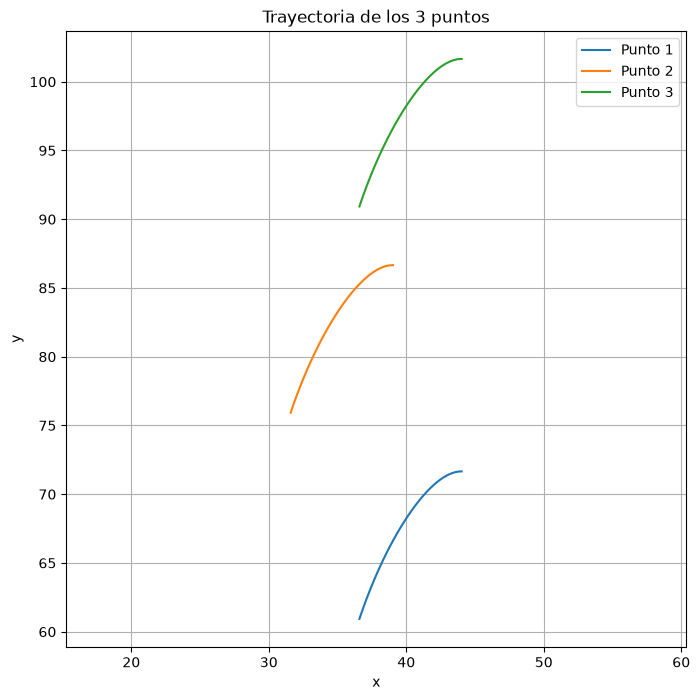

[np.float64(36.59191992186918), np.float64(36.64550875864572), np.float64(36.699626649472016), np.float64(36.75426789638674), np.float64(36.80942693881492), np.float64(36.86509835128847), np.float64(36.921276841191954), np.float64(36.97795724659158), np.float64(37.03513453414671), np.float64(37.09280379710309), np.float64(37.15096025336679), np.float64(37.20959924365842), np.float64(37.268716229746715), np.float64(37.32830679276138), np.float64(37.38836663158439), np.float64(37.44889156131986), np.float64(37.50987751184192), np.float64(37.57132052642072), np.float64(37.63321676042658), np.float64(37.69556248011263), np.float64(37.75835406147563), np.float64(37.82158798919626), np.float64(37.885260855658714), np.float64(37.949369360050795), np.float64(38.01391030754494), np.float64(38.07888060856173), np.float64(38.144277278116775), np.float64(38.210097435252166), np.float64(38.276338302554905), np.float64(38.342997205762956), np.float64(38.41007157346206), np.float64(38.47755893687487)

In [47]:
graficar_puntos(posicionesx_p1, posicionesy_p1, posicionesx_p2, posicionesy_p2, posicionesx_p3, posicionesy_p3)
print(posicionesx_p1)
print(posicionesx_p2)
print(posicionesx_p3)